# 📘 Week 15: Financial Time Series & Kalman Filtering
Welcome to Week 15 of the **Signal Processing Roadmap**! In this module, we will apply signal processing techniques to the domain of quantitative finance.

Financial price streams are highly noisy time series. We will explore how classical moving averages (**SMA** and **EMA**) attempt to extract trends, understand their limitations (specifically, the lag-filtering tradeoff), and study the **Kalman Filter** as an adaptive, optimal estimator. Finally, we will backtest a simple **algorithmic trading strategy** based on Kalman Filter crossovers.

## 🎯 Learning Objectives:
- Implement Simple Moving Average (SMA) and Exponential Moving Average (EMA) and analyze their time-lag tradeoffs.
- Formulate a 1D state-space representation for underlying stock prices.
- Implement a 1D Kalman Filter from scratch and understand the roles of process variance ($Q$) and measurement variance ($R$).
- Compare the smoothing performance of the Kalman Filter against SMA and EMA.
- Backtest a Kalman-crossover trading strategy and analyze its cumulative returns.

## 1. Financial Time Series & Moving Averages
Financial price streams (such as stock prices) are often modeled as a random walk (random drift) combined with market microstructure noise (e.g., bid-ask bounce, execution delay noise).

To extract trends, traders use moving averages:
1. **Simple Moving Average (SMA)**: An unweighted mean of the last $N$ prices.
2. **Exponential Moving Average (EMA)**: A weighted average that applies exponentially decreasing weights to older prices:
   $$\text{EMA}_t = \alpha \cdot P_t + (1 - \alpha) \cdot \text{EMA}_{t-1}$$
   Where $\alpha = 2 / (N + 1)$ is the smoothing factor.

Let's simulate a noisy stock price stream and apply both moving averages to visualize the inherent lag-filtering tradeoff.

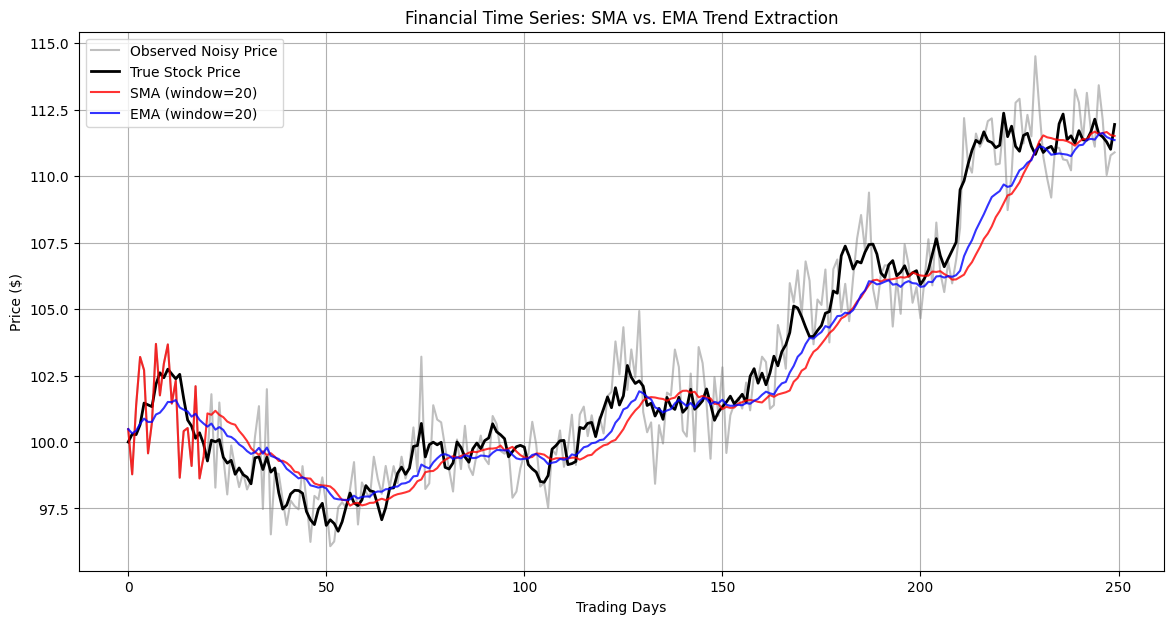

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulate Stock Price Series (250 trading days - ~1 year)
np.random.seed(42)
N_days = 250
t = np.arange(N_days)

# True underlying price (random walk with drift)
drift = 0.05
true_price = np.zeros(N_days)
true_price[0] = 100.0
for i in range(1, N_days):
    true_price[i] = true_price[i-1] + drift + np.random.normal(0, 0.5)

# Observed price with market microstructure noise
measurement_noise_std = 1.2
observed_price = true_price + np.random.normal(0, measurement_noise_std, N_days)

# 2. Simple Moving Average (SMA)
def calculate_sma(data, window):
    sma = np.empty_like(data)
    sma[:window] = data[:window] # Initial padding
    for i in range(window, len(data)):
        sma[i] = np.mean(data[i-window:i])
    return sma

# 3. Exponential Moving Average (EMA)
def calculate_ema(data, window):
    ema = np.empty_like(data)
    ema[0] = data[0]
    alpha = 2.0 / (window + 1)
    for i in range(1, len(data)):
        ema[i] = alpha * data[i] + (1 - alpha) * ema[i-1]
    return ema

window_size = 20
sma = calculate_sma(observed_price, window_size)
ema = calculate_ema(observed_price, window_size)

# Plotting the moving averages
plt.figure(figsize=(14, 7))
plt.plot(t, observed_price, 'gray', alpha=0.5, label='Observed Noisy Price')
plt.plot(t, true_price, 'black', linewidth=2, label='True Stock Price')
plt.plot(t, sma, 'red', label=f'SMA (window={window_size})', alpha=0.8)
plt.plot(t, ema, 'blue', label=f'EMA (window={window_size})', alpha=0.8)

plt.title("Financial Time Series: SMA vs. EMA Trend Extraction")
plt.xlabel("Trading Days")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()

### Observation:
- Notice how both SMA and EMA lag behind the true price curve, especially during rapid trend changes.
- The **EMA** reacts faster than the **SMA** to recent price movements (since it puts more weight on the latest samples), but still exhibits lag.

## 2. The 1D Kalman Filter from Scratch
The **Kalman Filter** provides an optimal estimation of the system state by modeling it recursively. For a simple 1D stock price tracker, let the underlying true price be our state $x_k$:
1. **State Equation**: $x_k = x_{k-1} + w_k$ where process noise $w_k \sim \mathcal{N}(0, Q)$. Process variance $Q$ represents how much the true price changes day-to-day (volatility).
2. **Measurement Equation**: $z_k = x_k + v_k$ where measurement noise $v_k \sim \mathcal{N}(0, R)$. Measurement variance $R$ represents bid-ask bounce and transient trading noise.

The Kalman Filter cycles through two main steps:
### Predict:
- Predicted state: $\hat{x}_{k|k-1} = \hat{x}_{k-1|k-1}$
- Predicted error covariance: $P_{k|k-1} = P_{k-1|k-1} + Q$

### Update:
- Innovation (Residual): $y_k = z_k - \hat{x}_{k|k-1}$
- Innovation covariance: $S_k = P_{k|k-1} + R$
- Kalman Gain: $K_k = P_{k|k-1} / S_k$
- Updated state: $\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k \cdot y_k$
- Updated error covariance: $P_{k|k} = (1 - K_k)P_{k|k-1}$

Let's implement this class and apply it to our simulated stock price.

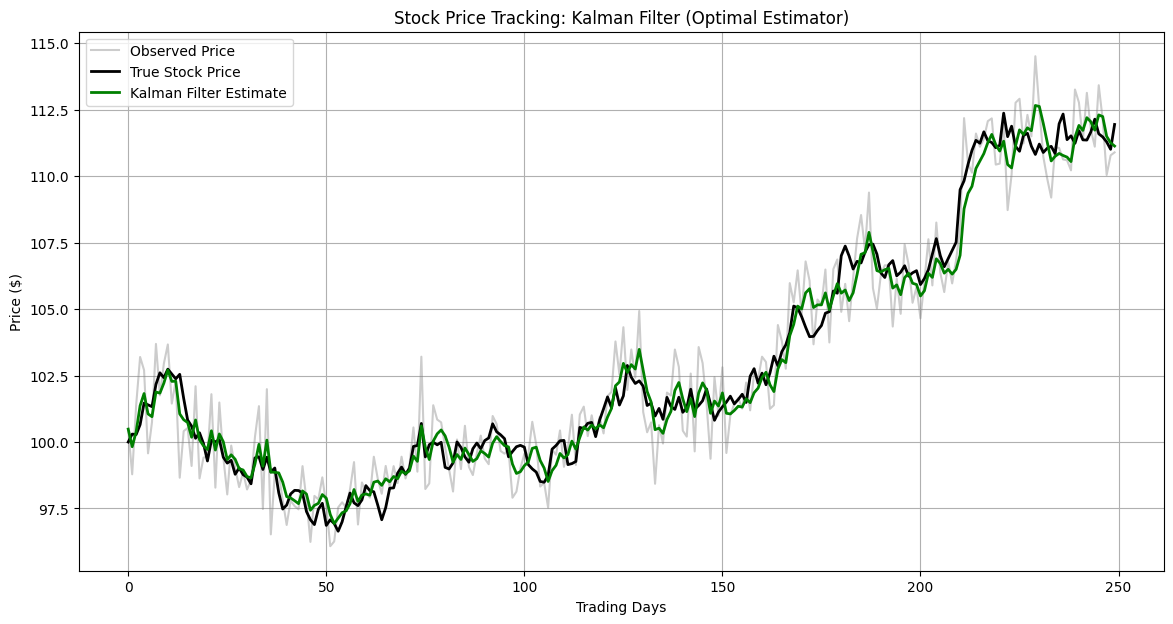

In [2]:
class KalmanFilter1D:
    def __init__(self, Q, R, initial_state=100.0, initial_error=1.0):
        self.Q = Q # Process noise variance
        self.R = R # Measurement noise variance
        self.x = initial_state # Current state estimate
        self.P = initial_error # Current error covariance

    def predict(self):
        # State transition: x_k = x_{k-1}
        # Covariance transition: P_k = P_{k-1} + Q
        self.P = self.P + self.Q

    def update(self, measurement):
        # Innovation / Residual: y = z - x
        y = measurement - self.x
        # Innovation covariance: S = P + R
        S = self.P + self.R
        # Kalman Gain: K = P / S
        K = self.P / S
        
        # Update state: x = x + K * y
        self.x = self.x + K * y
        # Update covariance: P = (1 - K) * P
        self.P = (1.0 - K) * self.P
        return self.x, K

# 1. Initialize Kalman Filter
# Q (process noise) represents actual daily price change variance (~0.5**2)
# R (measurement noise) represents bid-ask bounce variance (~1.2**2)
Q_var = 0.5**2
R_var = 1.2**2
kf = KalmanFilter1D(Q=Q_var, R=R_var, initial_state=observed_price[0])

kalman_estimates = []
kalman_gains = []

# 2. Run Kalman Filter recursively
for z in observed_price:
    kf.predict()
    est, gain = kf.update(z)
    kalman_estimates.append(est)
    kalman_gains.append(gain)

kalman_estimates = np.array(kalman_estimates)
kalman_gains = np.array(kalman_gains)

# Plotting Kalman Filter estimates
plt.figure(figsize=(14, 7))
plt.plot(t, observed_price, 'gray', alpha=0.4, label='Observed Price')
plt.plot(t, true_price, 'black', linewidth=2, label='True Stock Price')
plt.plot(t, kalman_estimates, 'green', linewidth=2, label='Kalman Filter Estimate')
plt.title("Stock Price Tracking: Kalman Filter (Optimal Estimator)")
plt.xlabel("Trading Days")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()

## 3. Performance Comparison: Kalman Filter vs. SMA/EMA
Let's compare the Root Mean Squared Error (RMSE) of the SMA, EMA, and Kalman Filter relative to the true underlying stock price to evaluate estimation accuracy.

Raw Observed RMSE: 1.1912
SMA RMSE:           1.2909
EMA RMSE:           1.0163
Kalman Filter RMSE: 0.6527


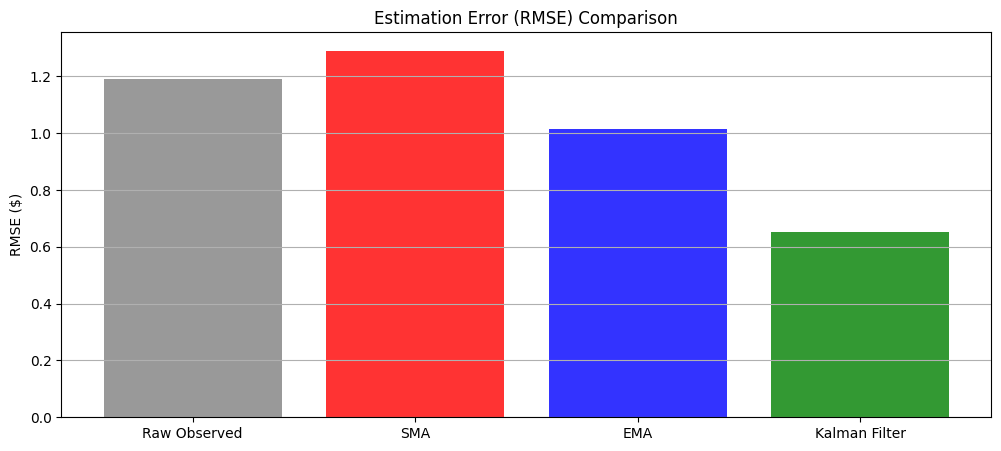

In [3]:
# Compute RMSE relative to true_price
rmse_observed = np.sqrt(np.mean((observed_price - true_price)**2))
rmse_sma = np.sqrt(np.mean((sma - true_price)**2))
rmse_ema = np.sqrt(np.mean((ema - true_price)**2))
rmse_kalman = np.sqrt(np.mean((kalman_estimates - true_price)**2))

print(f"Raw Observed RMSE: {rmse_observed:.4f}")
print(f"SMA RMSE:           {rmse_sma:.4f}")
print(f"EMA RMSE:           {rmse_ema:.4f}")
print(f"Kalman Filter RMSE: {rmse_kalman:.4f}")

# Plotting the error differences
plt.figure(figsize=(12, 5))
plt.bar(['Raw Observed', 'SMA', 'EMA', 'Kalman Filter'], 
        [rmse_observed, rmse_sma, rmse_ema, rmse_kalman],
        color=['gray', 'red', 'blue', 'green'], alpha=0.8)
plt.ylabel("RMSE ($)")
plt.title("Estimation Error (RMSE) Comparison")
plt.grid(axis='y')
plt.show()

### Why does the Kalman Filter outperform?
- The Kalman Filter dynamically adjusts its **Kalman Gain** ($K$) based on current uncertainty, effectively finding the optimal balance between tracking the trend (minimizing lag) and filtering the noise.
- SMA/EMA have fixed coefficients, meaning they cannot adapt to changing statistical properties of process or measurement noise.

## 4. Algorithmic Trading Crossover Strategy Backtest
We can build a simple algorithmic trading strategy using a crossover technique:
- **Buy (Go Long)**: When the observed price crosses *above* the Kalman Filter estimate (suggesting an upward breakout relative to smoothed value).
- **Sell (Go Short / Liquidate)**: When the observed price crosses *below* the Kalman Filter estimate (suggesting a downward breakdown).

Let's backtest this strategy and compare its performance to a simple **Buy & Hold** strategy.

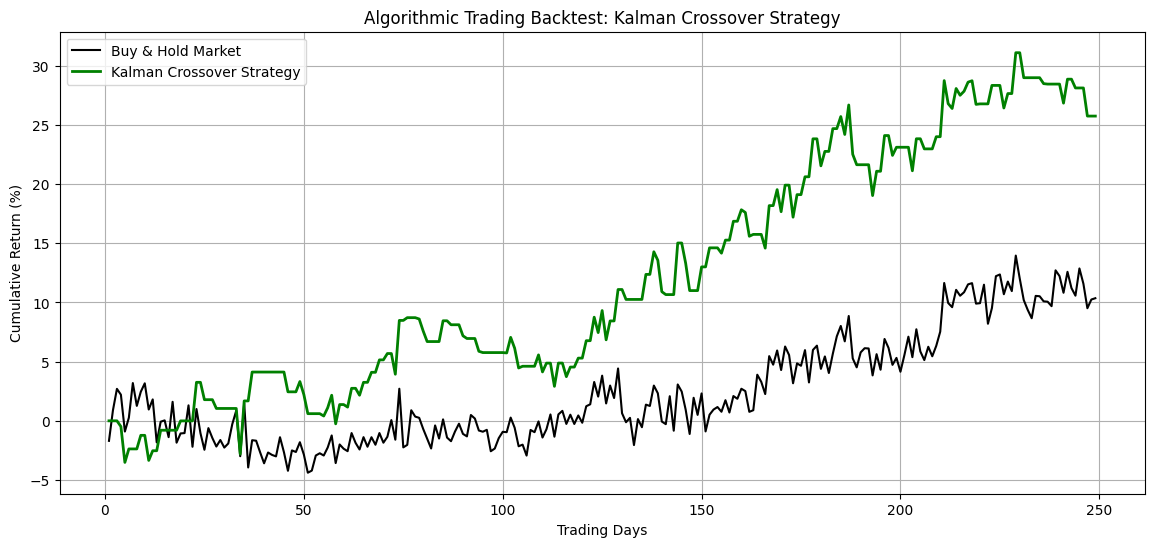

Final Market Return:   10.36%
Final Strategy Return: 25.74%


In [4]:
# Generate Trading Signals
# 1: Long Position, 0: Flat / Cash
signals = np.zeros(N_days)
positions = np.zeros(N_days)

for i in range(1, N_days):
    if observed_price[i] > kalman_estimates[i]:
        signals[i] = 1.0  # Buy signal
    else:
        signals[i] = 0.0  # Sell signal

# Shift signal by 1 day to prevent lookahead bias (trade next day)
positions[1:] = signals[:-1]

# Calculate Daily Returns
daily_market_returns = np.diff(observed_price) / observed_price[:-1]
daily_strategy_returns = positions[:-1] * daily_market_returns

# Cumulative returns
cum_market_returns = np.cumprod(1 + daily_market_returns) - 1.0
cum_strategy_returns = np.cumprod(1 + daily_strategy_returns) - 1.0

# Backtest Plot
t_returns = t[1:]
plt.figure(figsize=(14, 6))
plt.plot(t_returns, cum_market_returns * 100, 'black', label='Buy & Hold Market')
plt.plot(t_returns, cum_strategy_returns * 100, 'green', linewidth=2, label='Kalman Crossover Strategy')
plt.title("Algorithmic Trading Backtest: Kalman Crossover Strategy")
plt.xlabel("Trading Days")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True)
plt.show()

final_market_ret = cum_market_returns[-1] * 100
final_strategy_ret = cum_strategy_returns[-1] * 100
print(f"Final Market Return:   {final_market_ret:.2f}%")
print(f"Final Strategy Return: {final_strategy_ret:.2f}%")

## ✅ Reflection & Exercises
- **Filter Parameter Tuning**: In Section 2, modify $Q$ and $R$ to represent extremely high process noise ($Q=10.0, R=0.1$). Observe the Kalman estimate. Does it behave more like the noisy price or a smoothed line? What happens if $Q=0.001, R=10.0$?
- **Lag Analysis**: Compute and plot the daily lag (absolute difference from the true underlying price) for SMA, EMA, and Kalman Filter. Which tracking estimate aligns closest to the real value?